## Dlaczego potrzebujemy regresji logistycznej

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

Dane reprezentują zależność pomiędzy wynikiem testu SAT, a faktem dostania się do collegu ('Admited')

In [3]:
raw_data = pd.read_csv('Admittance.csv')
raw_data

,SAT,Admitted
0,1363,No
1,1792,Yes
2,1954,Yes
3,1653,No
4,1593,No
...,...,...
163,1722,Yes
164,1750,Yes
165,1555,No
166,1524,No


Zamieniamy Yes/No ana 1/0

In [4]:
data = raw_data.copy()
data['Admitted'] = data['Admitted'].map({'Yes':1, 'No': 0})  
data

,SAT,Admitted
0,1363,0
1,1792,1
2,1954,1
3,1653,0
4,1593,0
...,...,...
163,1722,1
164,1750,1
165,1555,0
166,1524,0


Deklarowanie zmiennych

In [5]:
y = data['Admitted'] 
x = data['SAT']  

Narysujmy wykres punktowy

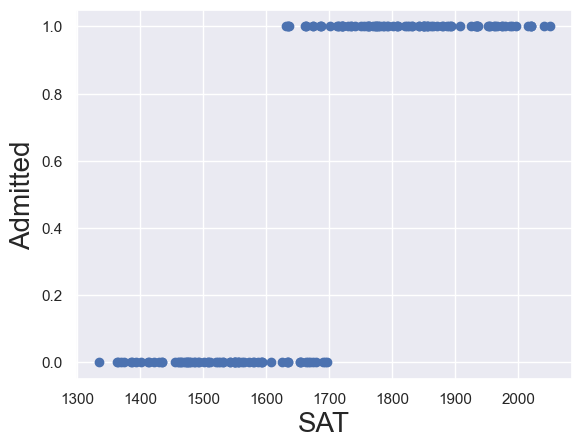

In [6]:
plt.scatter(x,y,color='C0')
plt.xlabel('SAT', fontsize=20)
plt.ylabel('Admitted', fontsize=20)
plt.show()

A teraz dodajmy prostą regresji

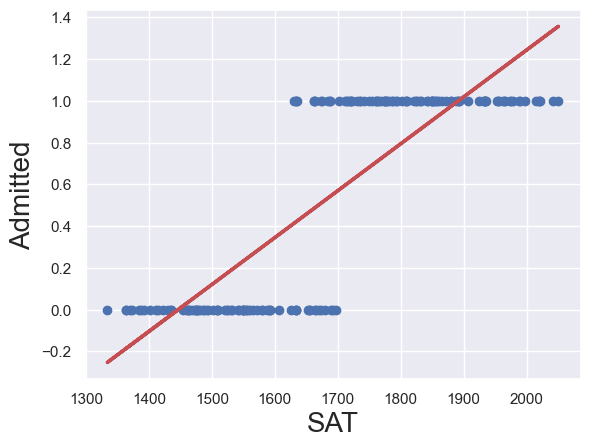

In [7]:
X = np.array(x).reshape(-1, 1)
lr = LinearRegression()  
lr.fit(X,y)
y_hat = lr.predict(X)  
plt.plot(x,y_hat, lw=2.5, color='C3')   

plt.scatter(x,y,color='C0')
plt.xlabel('SAT', fontsize=20)
plt.ylabel('Admitted', fontsize=20)
plt.show()

Regresja liniowa słabo odwzorowuje dane. Do tego część przewidywanych wartości jest poza dziedziną zmiennej 'Adnitted'. Zauważmy, że nie jest spełnione założenie o liniowej zależności zmiennej zależnej od zmiennej niezależnej. 

Właściwa krzywa regresji powinna wyglądać tak:

Krzywa regresji logistycznej

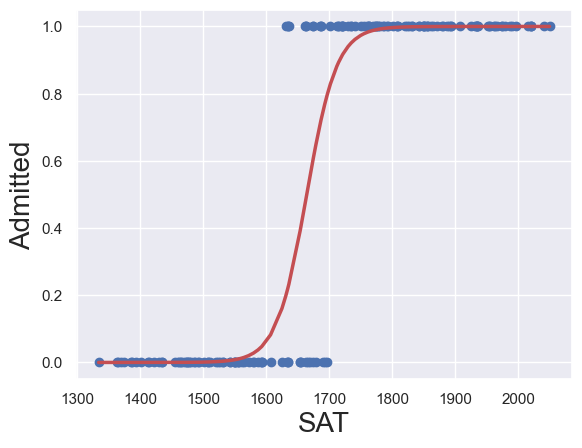

In [8]:
from sklearn.linear_model import LogisticRegression

reg_log = LogisticRegression(max_iter=100)
results_log = reg_log.fit(X,y)

def f(x,b0,b1):
    return np.array(np.exp(b0+x*b1)/(1+np.exp(b0+x*b1)))


f_sorted = np.sort(f(x,results_log.intercept_[0],results_log.coef_[0][0]))
x_sorted = np.sort(np.array(x))

plt.plot(x_sorted,f_sorted, lw=2.5, color='C3')  

plt.scatter(x,y,color='C0')
plt.xlabel('SAT', fontsize=20)
plt.ylabel('Admitted', fontsize=20)
plt.show()

**Interpretacja:** funkcja przedstawia **prawdopodobieństwo** dostania się do collegu dla danego wyniku SAT.

## Pierwszy model regresji logistycznej

Dopasowanie modelu

In [9]:
from sklearn.linear_model import LogisticRegression

reg_log = LogisticRegression(max_iter=100)
results_log = reg_log.fit(X,y)

Model regresji logistycznej ma postać  $\text{Admitted}=\beta_0+\beta_1\text{SAT}$

Wyznaczmy parametr $\beta_0$:

In [10]:
results_log.intercept_

array([-69.90656965])

oraz parametr $\beta_1$:

In [11]:
results_log.coef_

array([[0.04200113]])

Zatem model ma postać $\text{Admitted = -69.9+0.042\cdot SAT}$

Insterpretacja parametru $\beta_1$

In [16]:
print(f'Zwiększenie o 1 punkt na teście SAT zwiększa sansę na dostanie się do collegu {np.exp(results_log.coef_[0][0])} razy')
print(f'Zwiększenie o 10 punktów na teście SAT zwiększa sansę na dostanie się do collegu {np.exp(10*results_log.coef_[0][0])} razy')
print(f'Zwiększenie o 50 punktów na teście SAT zwiększa sansę na dostanie się do collegu {np.exp(50*results_log.coef_[0][0])} razy')

Zwiększenie o 1 punkt na teście SAT zwiększa sansę na dostanie się do collegu 1.0428956576275346 razy
Zwiększenie o 10 punktów na teście SAT zwiększa sansę na dostanie się do collegu 1.5219787597968903 razy
Zwiększenie o 50 punktów na teście SAT zwiększa sansę na dostanie się do collegu 8.166631472909305 razy


## Zmienne binarne w regresji logistycznej

In [17]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()  

In [18]:
raw_data = pd.read_csv('Binary predictors.csv')
raw_data

,SAT,Admitted,Gender
0,1363,No,Male
1,1792,Yes,Female
2,1954,Yes,Female
3,1653,No,Male
4,1593,No,Male
...,...,...,...
163,1722,Yes,Female
164,1750,Yes,Male
165,1555,No,Male
166,1524,No,Male


Zamiana Yes/No oraz Female/Male na 1/0

In [19]:
data = raw_data.copy()
data['Admitted'] = data['Admitted'].map({'Yes':1, 'No': 0})
data['Gender'] = data['Gender'].map({'Female':1, 'Male': 0})  
data

,SAT,Admitted,Gender
0,1363,0,0
1,1792,1,1
2,1954,1,1
3,1653,0,0
4,1593,0,0
...,...,...,...
163,1722,1,1
164,1750,1,0
165,1555,0,0
166,1524,0,0


Deklaracja zmiennych i tworzenie modelu

In [20]:
y = data['Admitted']  
X = data[['SAT','Gender']]  
reg_log = LogisticRegression(max_iter=100)
results_log = reg_log.fit(X,y)

parametr $\beta_0$

In [22]:
results_log.intercept_[0]

-66.90826843881712

parametry $\beta_1$ i $\beta_2$

In [24]:
results_log.coef_[0]

array([0.03991418, 1.17365038])

Model ma postać

$\log(\text{odds})=-66.91+0.040*\text{SAT}+1.174*\text{Gender}$

In [25]:
np.exp(1.174)

3.234906419426039

$\exp(1.174)\simeq 3.2$

Dla dwójki studentów (kobiety i mężczyzny) o tym samym wyniku SAT, kobieta ma 3.2 razy większe szansa na przyjęcie do collegu niż mężczyzna - to wynika z danych.

### Accuracy

Porównajmy wartości przewidywane przez model...

prawdopodobieństwa wystąpienia klas (not admitted, admitted) według modelu

In [31]:
np.set_printoptions(formatter={'float': lambda x: '{0:0.2f}'.format(x)}) # teraz numpy wyświetla tylko 2 liczby po przecinku
results_log.predict_proba(X)

array([[1.00, 0.00],
       [0.00, 1.00],
       [0.00, 1.00],
       [0.72, 0.28],
       [0.97, 0.03],
       [0.01, 0.99],
       [0.01, 0.99],
       [0.00, 1.00],
       [0.00, 1.00],
       [0.98, 0.02],
       [0.00, 1.00],
       [0.00, 1.00],
       [0.34, 0.66],
       [1.00, 0.00],
       [0.34, 0.66],
       [0.00, 1.00],
       [0.85, 0.15],
       [0.84, 0.16],
       [0.61, 0.39],
       [0.00, 1.00],
       [0.00, 1.00],
       [0.00, 1.00],
       [1.00, 0.00],
       [1.00, 0.00],
       [0.05, 0.95],
       [0.00, 1.00],
       [0.63, 0.37],
       [0.01, 0.99],
       [0.00, 1.00],
       [0.01, 0.99],
       [1.00, 0.00],
       [0.25, 0.75],
       [0.69, 0.31],
       [0.00, 1.00],
       [0.00, 1.00],
       [0.00, 1.00],
       [0.62, 0.38],
       [0.00, 1.00],
       [0.71, 0.29],
       [1.00, 0.00],
       [0.97, 0.03],
       [0.65, 0.35],
       [0.00, 1.00],
       [1.00, 0.00],
       [0.00, 1.00],
       [1.00, 0.00],
       [0.01, 0.99],
       [1.00,

prawdopodobieństwa tylko dla amitted

In [38]:
np.array([np.round(i[1],2) for i in results_log.predict_proba(X)])

array([0.00, 1.00, 1.00, 0.28, 0.03, 0.99, 0.99, 1.00, 1.00, 0.02, 1.00,
       1.00, 0.66, 0.00, 0.66, 1.00, 0.15, 0.16, 0.39, 1.00, 1.00, 1.00,
       0.00, 0.00, 0.95, 1.00, 0.37, 0.99, 1.00, 0.99, 0.00, 0.75, 0.31,
       1.00, 1.00, 1.00, 0.38, 1.00, 0.29, 0.00, 0.03, 0.35, 1.00, 0.00,
       1.00, 0.00, 0.99, 0.00, 0.00, 0.01, 0.01, 1.00, 0.88, 0.02, 1.00,
       0.00, 0.44, 0.97, 0.16, 0.99, 0.01, 0.82, 1.00, 1.00, 0.99, 0.00,
       0.00, 0.00, 1.00, 0.00, 0.82, 0.16, 0.00, 0.99, 1.00, 1.00, 0.00,
       0.37, 1.00, 1.00, 0.00, 1.00, 1.00, 0.78, 1.00, 1.00, 0.00, 1.00,
       1.00, 0.83, 0.75, 0.00, 0.97, 0.95, 0.00, 1.00, 1.00, 0.02, 0.99,
       0.93, 0.99, 0.00, 1.00, 0.02, 0.01, 0.99, 0.99, 1.00, 0.00, 0.00,
       0.03, 0.40, 0.00, 1.00, 0.11, 0.00, 0.95, 0.00, 0.65, 1.00, 1.00,
       0.02, 0.00, 0.00, 1.00, 0.01, 0.98, 0.63, 0.61, 0.90, 0.75, 0.00,
       1.00, 0.00, 0.00, 0.00, 1.00, 0.06, 0.00, 0.01, 1.00, 0.99, 0.59,
       0.99, 1.00, 0.04, 0.00, 0.00, 0.00, 0.74, 1.

In [37]:
y_pred = reg_log.predict(X)
y_pred

array([0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0], dtype=int64)

wartości prawdziwe

In [40]:
np.array(y)

array([0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0], dtype=int64)

Jeśli np. 80% wartości przewidywanych pokrywa się z prawdziwymi, to model ma 80% accuracy.

In [44]:
from sklearn.metrics import accuracy_score, confusion_matrix

cm = confusion_matrix(y,y_pred)
cm

array([[69,  5],
       [ 5, 89]], dtype=int64)

$\text{Confusion Matrix} =\begin{bmatrix}
\text{True Negative} & \text{False Positive} \\
\text{False Negative} & \text{True Positive} 
\end{bmatrix}=\begin{bmatrix}
69 & 5 \\
5 & 89 
\end{bmatrix}$

Model :
* Dla 69 obserwacji model przewidział 0, gdy wartość prawdziwa była 0 (True Negative)
* Dla 89 obserwacji model przewidział 1, gdy wartość prawdziwa była 1 (True Positive)
* Dla 4 obserwacji model przewidział 0, gdy wartość prawdziwa była 1 (False Negative)
* Dla 5 obserwacji model przewidział 1, gdy wartość prawdziwa była 0 (False Positive)

$\text{accuracy}=\frac{TN+TP}{TN+FN+FP+TP}=\frac{\text{dobrze przewidziane obserwacje}}{\text{wszystkie obserwacje}}=\frac{158}{168}=94\%$

In [47]:
reg_log.score(X,y)

0.9404761904761905

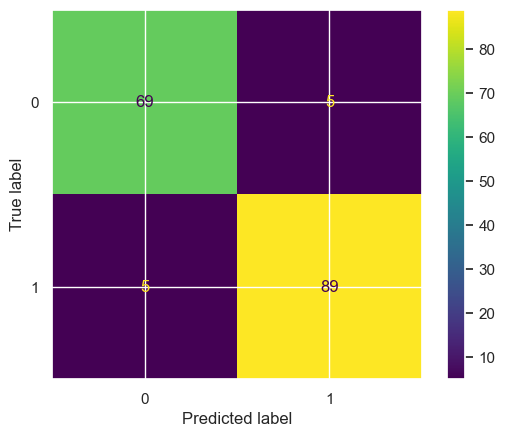

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=reg_log.classes_) 
                          
disp.plot()

plt.show()